In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**Setup & Installs**

In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rapidfuzz", "sentence-transformers"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "--no-deps", "pillow"], check=True)

import re, json, glob
from pathlib import Path
from functools import lru_cache
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import fuzz
from sentence_transformers import SentenceTransformer
from sklearn.metrics import matthews_corrcoef, accuracy_score

ROOT = Path("/kaggle/input/datasets/hemanthburada2003/dataset")
OUT_DIR = Path("/kaggle/working/eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


**Load Dataset**

In [3]:
csv_paths = glob.glob(str(ROOT / "**" / "*.csv"), recursive=True)
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found under {ROOT}")

dfs = {p: pd.read_csv(p) for p in csv_paths}

def _has_cols(df, cols):
    return all(c in df.columns for c in cols)

taxonomy_df = resumes_df = jds_df = gold_df = None
for p, df in dfs.items():
    if _has_cols(df, ["canonical_skill"]):
        taxonomy_df = df
    elif _has_cols(df, ["resume_text", "skill_mention_types"]):
        resumes_df = df
    elif _has_cols(df, ["jd_text", "required_skills"]):
        jds_df = df
    elif _has_cols(df, ["gold_match_score"]):
        gold_df = df

resumes = {str(r["resume_id"]): r for _, r in resumes_df.iterrows()}
jds = {str(r["jd_id"]): r for _, r in jds_df.iterrows()}

print(f"Loaded {len(resumes_df)} resumes, {len(jds_df)} JDs, {len(gold_df)} gold pairs, "
      f"{len(taxonomy_df)} taxonomy rows.")
resumes_df.head()

Loaded 500 resumes, 200 JDs, 250 gold pairs, 50 taxonomy rows.


,resume_id,name,category,years_experience,ground_truth_skills,skill_mention_types,resume_text
0,R0000,Priya Sharma,Data Science,2,"[""Natural Language Processing"", ""NumPy"", ""Pand...","{""Natural Language Processing"": ""exact"", ""NumP...",Priya Sharma\nProfessional Summary: Data Scien...
1,R0001,Deepa Kumar,Data Science,10,"[""Natural Language Processing"", ""TensorFlow"", ...","{""Natural Language Processing"": ""exact"", ""Tens...",Deepa Kumar\nProfessional Summary: Data Scienc...
2,R0002,Karan Joshi,Web Development,12,"[""React"", ""HTML"", ""Next.js"", ""Express.js"", ""No...","{""React"": ""exact"", ""HTML"": ""exact"", ""Next.js"":...",Karan Joshi\nProfessional Summary: Web Develop...
3,R0003,Kavya Singh,DevOps,11,"[""CI/CD"", ""Docker"", ""Terraform"", ""GCP"", ""AWS"",...","{""CI/CD"": ""exact"", ""Docker"": ""exact"", ""Terrafo...",Kavya Singh\nProfessional Summary: DevOps prof...
4,R0004,Rohan Singh,Human Resources,7,"[""Recruitment"", ""Performance Management"", ""Lab...","{""Recruitment"": ""exact"", ""Performance Manageme...",Rohan Singh\nProfessional Summary: Human Resou...


**Preprocessing (taxonomy build + text-cleaning primitives)**

In [4]:
FUZZY_VARIANTS, CONTEXTUAL_PHRASES = {}, {}
for _, row in taxonomy_df.iterrows():
    skill = str(row["canonical_skill"]).strip()
    variants = [v.strip() for v in str(row.get("fuzzy_variants", "") or "").split(";") if v.strip()]
    if variants:
        FUZZY_VARIANTS[skill] = variants
    paraphrase = str(row.get("contextual_paraphrase", "") or "").strip()
    if paraphrase and paraphrase.lower() != "nan":
        CONTEXTUAL_PHRASES[skill] = paraphrase

TIER_WEIGHTS = {"exact": 1.0, "fuzzy": 0.85, "contextual": 0.70, "none": 0.0}

def _normalize(text):
    return re.sub(r"\s+", " ", str(text).strip().lower())

_EMAIL_RE = re.compile(r"\S+@\S+\.\S+")
_URL_RE = re.compile(r"(https?://\S+|www\.\S+|linkedin\.com/\S+|github\.com/\S+)", re.IGNORECASE)
_PHONE_CANDIDATE_RE = re.compile(r"(\+?\d[\d\-\.\s\(\)]{5,}\d)")
_MULTI_WS_RE = re.compile(r"\s+")

def _strip_phone_numbers(text):
    def _repl(m):
        return " " if sum(1 for ch in m.group(0) if ch.isdigit()) >= 9 else m.group(0)
    return _PHONE_CANDIDATE_RE.sub(_repl, text)

def clean_for_semantic(text):
    if not text:
        return text
    cleaned = _EMAIL_RE.sub(" ", str(text))
    cleaned = _URL_RE.sub(" ", cleaned)
    cleaned = _strip_phone_numbers(cleaned)
    return _MULTI_WS_RE.sub(" ", cleaned).strip()

def _split_sentences(text):
    parts = re.split(r"[\n\r]+|(?<=[.;])\s+", str(text))
    return [p.strip() for p in parts if len(p.strip()) > 3]

def normalize_tier(tier):
    return str(tier).replace(" Match", "").strip()

print(f"Preprocessing ready: {len(FUZZY_VARIANTS)} skills with fuzzy variants, "
      f"{len(CONTEXTUAL_PHRASES)} skills with contextual paraphrases.")

Preprocessing ready: 50 skills with fuzzy variants, 16 skills with contextual paraphrases.


**Load Embedding Model + Matching Functions**

In [5]:
@lru_cache(maxsize=1)
def get_embedder():
    return SentenceTransformer("BAAI/bge-m3")

def _exact_match(skill, resume_norm):
    pattern = r"(?<![a-z0-9])" + re.escape(skill.lower()) + r"(?![a-z0-9])"
    return re.search(pattern, resume_norm) is not None

def _fuzzy_threshold_for(skill):
    length = len(skill)
    return 92.0 if length <= 4 else (85.0 if length <= 8 else 78.0)

def _fuzzy_match(skill, resume_norm):
    candidates = [skill] + FUZZY_VARIANTS.get(skill, [])
    words = resume_norm.split()
    threshold = _fuzzy_threshold_for(skill)
    for cand in candidates:
        cand_norm = _normalize(cand)
        cand_word_count = max(1, len(cand_norm.split()))
        spans = {s for s in (cand_word_count - 1, cand_word_count, cand_word_count + 1) if s > 0}
        for span in spans:
            windows = [" ".join(words[i:i + span]) for i in range(max(0, len(words) - span + 1))]
            for w in windows:
                if not w:
                    continue
                score = max(fuzz.ratio(cand_norm, w), fuzz.token_sort_ratio(cand_norm, w))
                if score >= threshold:
                    return True
    return False

@lru_cache(maxsize=4096)
def _cached_resume_sentences_and_embeddings(resume_text):
    sentences = _split_sentences(resume_text)
    if not sentences:
        return tuple(), None
    vecs = get_embedder().encode(sentences, batch_size=32, normalize_embeddings=True)
    return tuple(sentences), vecs

@lru_cache(maxsize=None)
def _cached_phrase_embedding(phrase):
    return get_embedder().encode([phrase], normalize_embeddings=True)[0]

@lru_cache(maxsize=50000)
def _contextual_raw_score(skill, resume_text):
    phrase = CONTEXTUAL_PHRASES.get(skill)
    if not phrase:
        return None
    sentences, sent_vecs = _cached_resume_sentences_and_embeddings(resume_text)
    if not sentences:
        return None
    phrase_vec = _cached_phrase_embedding(phrase)
    skill_lower = skill.lower()
    idxs = [i for i, s in enumerate(sentences) if skill_lower not in s.lower()]
    if not idxs:
        return None
    return max(float(sent_vecs[i] @ phrase_vec) for i in idxs)

def skill_match_info(skill, resume_text):
    resume_norm = _normalize(resume_text)
    if _exact_match(skill, resume_norm):
        return "exact", None
    if _fuzzy_match(skill, resume_norm):
        return "fuzzy", None
    return None, _contextual_raw_score(skill, resume_text)

def resolve_tier(base_tier, contextual_score, threshold):
    if base_tier is not None:
        return base_tier
    if contextual_score is not None and contextual_score >= threshold:
        return "contextual"
    return "none"

def embed_resume(resume_text):
    resume_clean = clean_for_semantic(resume_text)
    if not resume_clean:
        return None
    return get_embedder().encode([resume_clean], normalize_embeddings=True)[0]

@lru_cache(maxsize=2048)
def semantic_similarity_cached(resume_text, jd_text):
    jd_clean = clean_for_semantic(jd_text)
    if not jd_clean:
        return 0.0
    resume_vec = embed_resume(resume_text)
    if resume_vec is None:
        return 0.0
    jd_vec = get_embedder().encode([jd_clean], normalize_embeddings=True)[0]
    cosine = float(np.dot(resume_vec, jd_vec))
    return round(max(0.0, min(1.0, cosine)), 4)

print("Embedder loaded and matching functions ready.")

Embedder loaded and matching functions ready.


**Feature Extraction (precompute Φ_sem and skill match info once)**

In [6]:
print("Precomputing embeddings + match info for gold pairs...")
precomp = []
for i, pair in gold_df.iterrows():
    resume = resumes.get(str(pair["resume_id"]))
    jd = jds.get(str(pair["jd_id"]))
    if resume is None or jd is None:
        continue
    required_skills = json.loads(jd["required_skills"])
    phi_sem = semantic_similarity_cached(resume["resume_text"], jd["jd_text"])
    skill_records = [skill_match_info(s, resume["resume_text"]) for s in required_skills]
    precomp.append({
        "resume_id": pair["resume_id"], "jd_id": pair["jd_id"],
        "gold_score": float(pair["gold_match_score"]),
        "gold_tier": normalize_tier(pair["gold_match_tier"]),
        "phi_sem": phi_sem, "skill_records": skill_records,
    })
    if (i + 1) % 50 == 0:
        print(f"  ...{i + 1}/{len(gold_df)} pairs embedded")

print(f"Feature extraction done: {len(precomp)} pairs ready for training.")

def theta_for_threshold(skill_records, threshold):
    if not skill_records:
        return 0.0
    total = sum(TIER_WEIGHTS[resolve_tier(bt, sc, threshold)] for bt, sc in skill_records)
    return total / len(skill_records)

def evaluate_config(semantic_weight, contextual_threshold, best_cut, avg_cut):
    predicted_scores, gold_scores, predicted_tiers, gold_tiers = [], [], [], []
    for rec in precomp:
        theta = theta_for_threshold(rec["skill_records"], contextual_threshold)
        s1 = (semantic_weight * rec["phi_sem"] + (1 - semantic_weight) * theta) * 100
        tier = "Low"
        if s1 >= best_cut:
            tier = "Best"
        elif s1 >= avg_cut:
            tier = "Average"
        predicted_scores.append(s1)
        gold_scores.append(rec["gold_score"])
        predicted_tiers.append(tier)
        gold_tiers.append(rec["gold_tier"])
    corr = float(pd.Series(predicted_scores).corr(pd.Series(gold_scores)))
    tier_acc = float(np.mean([p == g for p, g in zip(predicted_tiers, gold_tiers)]))
    mcc = matthews_corrcoef(gold_tiers, predicted_tiers)
    return corr, tier_acc, mcc, predicted_scores, predicted_tiers, gold_tiers

Precomputing embeddings + match info for gold pairs...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

  ...50/250 pairs embedded
  ...100/250 pairs embedded
  ...150/250 pairs embedded
  ...200/250 pairs embedded
  ...250/250 pairs embedded
Feature extraction done: 250 pairs ready for training.


**"Training" / Hyperparameter Tuning (Sweep A: weight + threshold)**

In [7]:
print("=== Training Sweep A: semantic_weight x contextual_threshold ===")
semantic_weights = [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70]
contextual_thresholds = [0.45, 0.50, 0.55, 0.60, 0.65]

sweep_a_rows = []
for sw, th in product(semantic_weights, contextual_thresholds):
    corr, tier_acc, mcc, *_ = evaluate_config(sw, th, best_cut=70, avg_cut=40)
    sweep_a_rows.append({"semantic_weight": sw, "contextual_threshold": th,
                          "pearson_corr": round(corr, 4), "tier_accuracy": round(tier_acc, 4),
                          "overall_mcc": round(mcc, 4)})

sweep_a_df = pd.DataFrame(sweep_a_rows).sort_values(
    ["tier_accuracy", "overall_mcc"], ascending=False).reset_index(drop=True)
sweep_a_df.to_csv(OUT_DIR / "sweep_weight_threshold.csv", index=False)
print(sweep_a_df.head(10).to_string(index=False))

best_sw = float(sweep_a_df.iloc[0]["semantic_weight"])
best_th = float(sweep_a_df.iloc[0]["contextual_threshold"])
print(f"\nBest hyperparameters found: semantic_weight={best_sw}, contextual_threshold={best_th}")

=== Training Sweep A: semantic_weight x contextual_threshold ===
 semantic_weight  contextual_threshold  pearson_corr  tier_accuracy  overall_mcc
            0.30                  0.65        0.9856          0.928       0.8937
            0.40                  0.65        0.9851          0.916       0.8777
            0.30                  0.60        0.9775          0.912       0.8663
            0.40                  0.60        0.9771          0.900       0.8523
            0.30                  0.55        0.9657          0.896       0.8389
            0.45                  0.65        0.9845          0.884       0.8363
            0.30                  0.50        0.9622          0.884       0.8205
            0.45                  0.60        0.9765          0.872       0.8158
            0.40                  0.55        0.9655          0.872       0.8103
            0.50                  0.65        0.9835          0.864       0.8141

Best hyperparameters found: semantic_weight

**"Training" continued (Sweep B: tier cutoffs)**

In [8]:
print("=== Training Sweep B: tier score cutoffs ===")
best_cuts = list(range(55, 86, 5))
avg_cuts = list(range(25, 56, 5))

sweep_b_rows = []
for bc, ac in product(best_cuts, avg_cuts):
    if ac >= bc:
        continue
    corr, tier_acc, mcc, *_ = evaluate_config(best_sw, best_th, best_cut=bc, avg_cut=ac)
    sweep_b_rows.append({"best_cut": bc, "avg_cut": ac,
                          "pearson_corr": round(corr, 4), "tier_accuracy": round(tier_acc, 4),
                          "overall_mcc": round(mcc, 4)})

sweep_b_df = pd.DataFrame(sweep_b_rows).sort_values(
    ["tier_accuracy", "overall_mcc"], ascending=False).reset_index(drop=True)
sweep_b_df.to_csv(OUT_DIR / "sweep_cutoffs.csv", index=False)
print(sweep_b_df.head(10).to_string(index=False))

best_cut = int(sweep_b_df.iloc[0]["best_cut"])
avg_cut = int(sweep_b_df.iloc[0]["avg_cut"])
print(f"\nBest cutoffs found: best_cut={best_cut}, avg_cut={avg_cut}")

=== Training Sweep B: tier score cutoffs ===
 best_cut  avg_cut  pearson_corr  tier_accuracy  overall_mcc
       65       40        0.9856          0.936       0.8996
       65       45        0.9856          0.936       0.8992
       65       50        0.9856          0.932       0.8928
       70       40        0.9856          0.928       0.8937
       70       45        0.9856          0.928       0.8926
       65       35        0.9856          0.928       0.8876
       70       50        0.9856          0.924       0.8844
       70       35        0.9856          0.920       0.8827
       65       30        0.9856          0.912       0.8642
       70       30        0.9856          0.904       0.8611

Best cutoffs found: best_cut=65, avg_cut=40


**Testing (final evaluation with best config)**

In [9]:
print(f"=== Final Test: semantic_weight={best_sw}, contextual_threshold={best_th}, "
      f"best_cut={best_cut}, avg_cut={avg_cut} ===")
corr, tier_acc, mcc, predicted_scores, predicted_tiers, gold_tiers = evaluate_config(
    best_sw, best_th, best_cut, avg_cut)
print(f"Pearson correlation: {corr:.4f}")
print(f"Tier agreement accuracy: {tier_acc:.4f}")
print(f"Overall MCC: {mcc:.4f}")

final_rows = []
for tier in ["Best", "Average", "Low"]:
    y_true = np.array(gold_tiers)
    y_pred = np.array(predicted_tiers)
    tp = int(((y_true == tier) & (y_pred == tier)).sum())
    fp = int(((y_true != tier) & (y_pred == tier)).sum())
    fn = int(((y_true == tier) & (y_pred != tier)).sum())
    tn = int(((y_true != tier) & (y_pred != tier)).sum())
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    denom = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    tier_mcc = (tp * tn - fp * fn) / denom if denom else float("nan")
    acc = (tp + tn) / (tp + fp + fn + tn)
    final_rows.append({"tier": tier, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                        "precision": round(precision, 4), "recall": round(recall, 4),
                        "mcc_one_vs_rest": round(tier_mcc, 4), "accuracy_one_vs_rest": round(acc, 4)})
final_rows.append({"tier": "Overall", "tp": "", "fp": "", "fn": "", "tn": "",
                    "precision": "", "recall": "",
                    "mcc_one_vs_rest": round(mcc, 4),
                    "accuracy_one_vs_rest": round(accuracy_score(gold_tiers, predicted_tiers), 4)})
final_df = pd.DataFrame(final_rows)
final_df.to_csv(OUT_DIR / "best_config_tier_metrics.csv", index=False)
print(final_df.to_string(index=False))

with open(OUT_DIR / "best_config.json", "w") as f:
    json.dump({"semantic_weight": best_sw, "skill_weight": round(1 - best_sw, 2),
               "contextual_threshold": best_th, "best_cut": best_cut, "avg_cut": avg_cut,
               "pearson_corr": round(corr, 4), "tier_accuracy": round(tier_acc, 4),
               "overall_mcc": round(mcc, 4)}, f, indent=2)

=== Final Test: semantic_weight=0.3, contextual_threshold=0.65, best_cut=65, avg_cut=40 ===
Pearson correlation: 0.9856
Tier agreement accuracy: 0.9360
Overall MCC: 0.8996
   tier tp fp fn  tn precision  recall  mcc_one_vs_rest  accuracy_one_vs_rest
   Best 97  8  4 141    0.9238  0.9604           0.9014                 0.952
Average 39  8  8 195    0.8298  0.8298           0.7904                 0.936
    Low 98  0  4 148       1.0  0.9608           0.9672                 0.984
Overall                                          0.8996                 0.936


**Testing: Skill-cascade recall check**

In [10]:
print("Precomputing match info for skill cascade...")
cascade_precomp = []
for i, (_, resume) in enumerate(resumes_df.iterrows()):
    ground_truth = json.loads(resume["skill_mention_types"])
    for skill, true_tier in ground_truth.items():
        base_tier, score = skill_match_info(skill, resume["resume_text"])
        cascade_precomp.append((true_tier, base_tier, score))
    if (i + 1) % 100 == 0:
        print(f"  ...{i + 1}/{len(resumes_df)} resumes processed")

cascade_sweep_rows = []
for th in contextual_thresholds:
    counts = {"exact": [0, 0], "fuzzy": [0, 0], "contextual": [0, 0]}
    for true_tier, base_tier, score in cascade_precomp:
        if true_tier not in counts:
            continue
        pred_tier = resolve_tier(base_tier, score, th)
        counts[true_tier][1] += 1
        if pred_tier == true_tier:
            counts[true_tier][0] += 1
    row = {"contextual_threshold": th}
    for tier, (c, t) in counts.items():
        row[f"{tier}_recall"] = round(c / t, 4) if t else float("nan")
    cascade_sweep_rows.append(row)

cascade_sweep_df = pd.DataFrame(cascade_sweep_rows)
cascade_sweep_df.to_csv(OUT_DIR / "sweep_cascade_recall.csv", index=False)
print(cascade_sweep_df.to_string(index=False))
print(f"\nAll results saved to {OUT_DIR}")

Precomputing match info for skill cascade...
  ...100/500 resumes processed
  ...200/500 resumes processed
  ...300/500 resumes processed
  ...400/500 resumes processed
  ...500/500 resumes processed
 contextual_threshold  exact_recall  fuzzy_recall  contextual_recall
                 0.45           1.0         0.695             0.9946
                 0.50           1.0         0.695             0.9946
                 0.55           1.0         0.695             0.9946
                 0.60           1.0         0.695             0.9946
                 0.65           1.0         0.695             0.9946

All results saved to /kaggle/working/eval_results


**Plot Results**

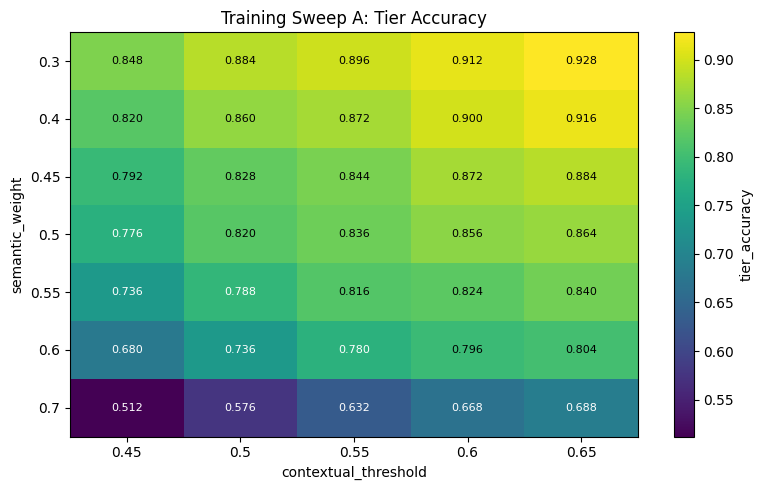

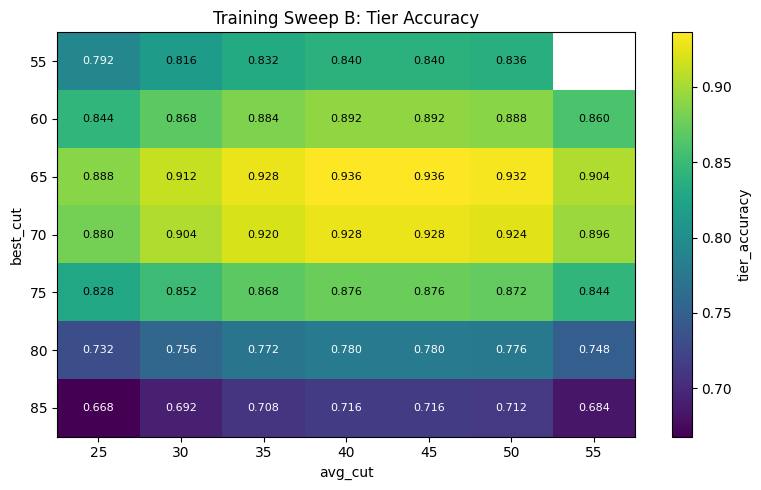

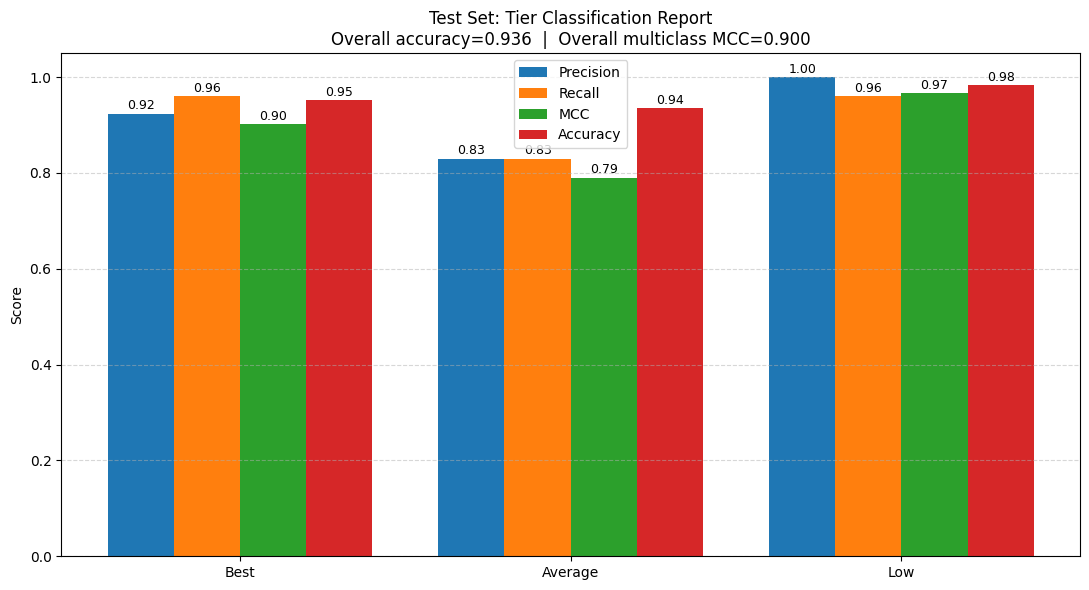

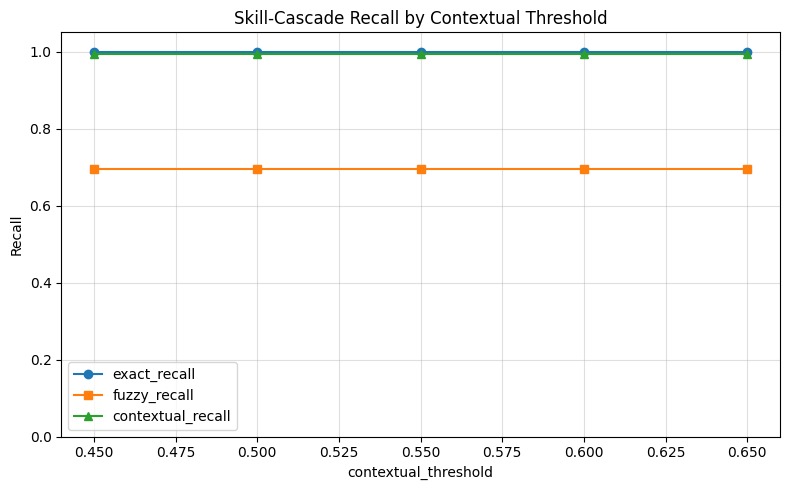

All plots saved to /kaggle/working/eval_results


In [11]:
# Sweep A heatmap
pivot_a = sweep_a_df.pivot(index="semantic_weight", columns="contextual_threshold", values="tier_accuracy")
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_a.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot_a.columns))); ax.set_xticklabels(pivot_a.columns)
ax.set_yticks(range(len(pivot_a.index))); ax.set_yticklabels(pivot_a.index)
ax.set_xlabel("contextual_threshold"); ax.set_ylabel("semantic_weight")
ax.set_title("Training Sweep A: Tier Accuracy")
for i in range(pivot_a.shape[0]):
    for j in range(pivot_a.shape[1]):
        ax.text(j, i, f"{pivot_a.values[i, j]:.3f}", ha="center", va="center",
                 color="white" if pivot_a.values[i, j] < pivot_a.values.max()*0.85 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="tier_accuracy")
plt.tight_layout(); plt.savefig(OUT_DIR / "plot_sweep_a_heatmap.png", dpi=150); plt.show()

# Sweep B heatmap
pivot_b = sweep_b_df.pivot(index="best_cut", columns="avg_cut", values="tier_accuracy")
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_b.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot_b.columns))); ax.set_xticklabels(pivot_b.columns)
ax.set_yticks(range(len(pivot_b.index))); ax.set_yticklabels(pivot_b.index)
ax.set_xlabel("avg_cut"); ax.set_ylabel("best_cut")
ax.set_title("Training Sweep B: Tier Accuracy")
for i in range(pivot_b.shape[0]):
    for j in range(pivot_b.shape[1]):
        val = pivot_b.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                     color="white" if val < np.nanmax(pivot_b.values)*0.85 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="tier_accuracy")
plt.tight_layout(); plt.savefig(OUT_DIR / "plot_sweep_b_heatmap.png", dpi=150); plt.show()

# Final test tier classification report
tier_rows = final_df[final_df["tier"] != "Overall"].copy()
overall_row = final_df[final_df["tier"] == "Overall"].iloc[0]
tiers = tier_rows["tier"].tolist()
precision = tier_rows["precision"].astype(float).tolist()
recall = tier_rows["recall"].astype(float).tolist()
mccs = tier_rows["mcc_one_vs_rest"].astype(float).tolist()
accuracy = tier_rows["accuracy_one_vs_rest"].astype(float).tolist()
x = np.arange(len(tiers)); width = 0.2
fig, ax = plt.subplots(figsize=(11, 6))
groups = [
    ax.bar(x - 1.5*width, precision, width, label="Precision", color="tab:blue"),
    ax.bar(x - 0.5*width, recall,    width, label="Recall",    color="tab:orange"),
    ax.bar(x + 0.5*width, mccs,      width, label="MCC",       color="tab:green"),
    ax.bar(x + 1.5*width, accuracy,  width, label="Accuracy",  color="tab:red"),
]
for group in groups:
    for rect in group:
        h = rect.get_height()
        ax.annotate(f"{h:.2f}", xy=(rect.get_x()+rect.get_width()/2, h),
                     xytext=(0,3), textcoords="offset points", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(tiers); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title(f"Test Set: Tier Classification Report\n"
             f"Overall accuracy={float(overall_row['accuracy_one_vs_rest']):.3f}  |  "
             f"Overall multiclass MCC={float(overall_row['mcc_one_vs_rest']):.3f}")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / "plot_tier_classification_report.png", dpi=150); plt.show()

# Cascade recall
fig, ax = plt.subplots(figsize=(8, 5))
for col, marker in zip(["exact_recall", "fuzzy_recall", "contextual_recall"], ["o", "s", "^"]):
    ax.plot(cascade_sweep_df["contextual_threshold"], cascade_sweep_df[col], marker=marker, label=col)
ax.set_xlabel("contextual_threshold"); ax.set_ylabel("Recall")
ax.set_title("Skill-Cascade Recall by Contextual Threshold")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.savefig(OUT_DIR / "plot_cascade_recall.png", dpi=150); plt.show()

print(f"All plots saved to {OUT_DIR}")

In [12]:
import shutil
shutil.make_archive("/kaggle/working/eval_results_bundle", "zip", "/kaggle/working/eval_results")
print("Zipped to /kaggle/working/eval_results_bundle.zip")

Zipped to /kaggle/working/eval_results_bundle.zip


In [13]:
# ---------------------------------------------------------------------------
# gold_pair_results.csv -- per-pair predicted vs gold score/tier, matching
# evaluate_dataset.py's schema exactly.
# ---------------------------------------------------------------------------

gold_pair_rows = []
for pair_id_i, rec in enumerate(precomp):
    theta = theta_for_threshold(rec["skill_records"], best_th)
    s1 = round((best_sw * rec["phi_sem"] + (1 - best_sw) * theta) * 100, 2)

    tier = "Low"
    if s1 >= best_cut:
        tier = "Best"
    elif s1 >= avg_cut:
        tier = "Average"

    gold_pair_rows.append({
        "pair_id": f"P{pair_id_i:04d}",
        "resume_id": rec["resume_id"],
        "jd_id": rec["jd_id"],
        "phi_sem": rec["phi_sem"],
        "theta_skill": round(theta, 4),
        "predicted_score": s1,
        "gold_score": rec["gold_score"],
        "predicted_tier": tier,
        "gold_tier": rec["gold_tier"],
        "tier_match": tier == rec["gold_tier"],
    })

gold_pair_df = pd.DataFrame(gold_pair_rows)
gold_pair_df.to_csv(OUT_DIR / "gold_pair_results.csv", index=False)

corr_check = gold_pair_df["predicted_score"].corr(gold_pair_df["gold_score"])
tier_acc_check = (gold_pair_df["tier_match"]).mean()
print(f"gold_pair_results.csv: {len(gold_pair_df)} rows written")
print(f"  Pearson correlation: {corr_check:.4f}")
print(f"  Tier agreement accuracy: {tier_acc_check:.4f}")

# ---------------------------------------------------------------------------
# skill_cascade_results.csv -- per-skill, per-resume true vs predicted tier,
# matching evaluate_dataset.py's schema exactly.
# ---------------------------------------------------------------------------

print("\nPrecomputing skill cascade with resume_id + skill retained...")
cascade_rows = []
for i, (_, resume) in enumerate(resumes_df.iterrows()):
    ground_truth = json.loads(resume["skill_mention_types"])
    for skill, true_tier in ground_truth.items():
        base_tier, score = skill_match_info(skill, resume["resume_text"])
        predicted_tier = resolve_tier(base_tier, score, best_th)
        cascade_rows.append({
            "resume_id": resume["resume_id"],
            "skill": skill,
            "true_tier": true_tier,
            "predicted_tier": predicted_tier,
            "match": predicted_tier == true_tier,
        })
    if (i + 1) % 100 == 0:
        print(f"  ...{i + 1}/{len(resumes_df)} resumes processed")

cascade_df = pd.DataFrame(cascade_rows)
cascade_df.to_csv(OUT_DIR / "skill_cascade_results.csv", index=False)

print(f"\nskill_cascade_results.csv: {len(cascade_df)} rows written")
print("Per-tier recall:")
for tier in ["exact", "fuzzy", "contextual"]:
    subset = cascade_df[cascade_df["true_tier"] == tier]
    if len(subset):
        recall = subset["match"].mean()
        print(f"  {tier:12s}: {subset['match'].sum()}/{len(subset)} = {recall:.4f}")

print(f"\nBoth files written to {OUT_DIR}")

gold_pair_results.csv: 250 rows written
  Pearson correlation: 0.9856
  Tier agreement accuracy: 0.9360

Precomputing skill cascade with resume_id + skill retained...
  ...100/500 resumes processed
  ...200/500 resumes processed
  ...300/500 resumes processed
  ...400/500 resumes processed
  ...500/500 resumes processed

skill_cascade_results.csv: 4250 rows written
Per-tier recall:
  exact       : 3505/3505 = 1.0000
  fuzzy       : 262/377 = 0.6950
  contextual  : 366/368 = 0.9946

Both files written to /kaggle/working/eval_results
